# Load and cleaning data inflasi 2026

In [8]:
import pandas as pd
import numpy as np

months = [
    'Januari',
    'Februari',
    'Maret',
    'April',
    'Mei',
    'Juni',
    'Juli',
    'Agustus',
    'September',
    'Oktober',
    'November',
    'Desember'
]
month_mapping = {
    'Januari': '01',
    'Februari': '02',
    'Maret': '03',
    'April': '04',
    'Mei': '05',
    'Juni': '06',
    'Juli': '07',
    'Agustus': '08',
    'September': '09',
    'Oktober': '10',
    'November': '11',
    'Desember': '12'
}

In [ ]:
df_inf_2026 = pd.read_csv("../Data/Test_data/Inflasi Bulanan (M-to-M), 2026.csv", skiprows=3)

# Filter data INDONESIA
df_indo_2026 = df_inf_2026[df_inf_2026['Unnamed: 0'].astype(str).str.strip().str.upper() == 'INDONESIA'].copy()

# format data dari wide ke long
tahun_2026 = "2026"
df_melt_2026 = df_indo_2026.melt(id_vars=['Unnamed: 0'], value_vars=months, var_name='Bulan', value_name='Inflasi')
df_melt_2026['Tahun'] = tahun_2026
df_melt_2026['Inflasi'] = pd.to_numeric(df_melt_2026['Inflasi'], errors='coerce')

# Map nama bulan menjadi angka (1-12) untuk kebutuhan regresi
df_melt_2026['Bulan_Angka'] = df_melt_2026['Bulan'].map(month_mapping)
df_melt_2026['Tanggal'] = pd.to_datetime(df_melt_2026['Tahun'] + '-' + df_melt_2026['Bulan_Angka'])
df_melt_2026 = df_melt_2026[['Tanggal', 'Tahun', 'Bulan', 'Inflasi']]

# gunakan rata-rata untuk data inflasi yang kosong
rata_rata_2026 = df_melt_2026['Inflasi'].mean()
print(f"Rata-rata inflasi tahun 2026 adalah: {rata_rata_2026:.4f}%")
df_melt_2026['Inflasi'] = df_melt_2026['Inflasi'].fillna(rata_rata_2026)
df_melt_2026.head()

# Load data from AIVEN Database

In [ ]:
!pip install sqlalchemy pymysql

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text
from sklearn.linear_model import LinearRegression

In [ ]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")

#inisiasi db
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

In [ ]:
df_train_data = pd.read_sql(
    text("SELECT * FROM forecast_kereta ORDER BY Tanggal ASC"),
    engine
)

df_train_data['Tanggal'] = pd.to_datetime(df_train_data['Tanggal'])
df_train_data['Bulan_Angka'] = df_train_data['Tanggal'].dt.month
df_train_data['Time_Index'] = df_train_data.groupby('Kategori').cumcount() + 1

df_train_data.head()

# Train machine learning dan Forecasting

In [93]:
list_hasil_prediksi = []
kategori_unik = df_train_data['Kategori'].unique()

for kat in kategori_unik:
    # Filter data latih
    df_kat = df_train_data[df_train_data['Kategori'] == kat].copy()

    X_train = df_kat[['Time_Index', 'Bulan_Angka', 'Inflasi']]
    y_train = df_kat['Jumlah_Penumpang_Ribu']

    # Latih model dengan regresi linear
    model = LinearRegression()
    model.fit(X_train, y_train)

    # copy data inflasi 2026 sebagai X
    df_pred_kat = df_melt_2026.copy()
    df_pred_kat['Bulan_Angka'] = df_pred_kat['Bulan'].map(month_mapping)
    df_pred_kat['Kategori'] = kat
    df_pred_kat['Time_Index'] = np.arange(25, 25 + len(df_pred_kat)) #time index 25-N

    X_test = df_pred_kat[['Time_Index', 'Bulan_Angka', 'Inflasi']]

    #Forecasting
    df_pred_kat['Prediksi_Penumpang_Ribu'] = model.predict(X_test)

    list_hasil_prediksi.append(df_pred_kat)

# merge hasil forecasting
df_final_2026 = pd.concat(list_hasil_prediksi, ignore_index=True)
df_final_2026 = df_final_2026[['Tanggal', 'Tahun', 'Bulan', 'Inflasi', 'Kategori', 'Prediksi_Penumpang_Ribu', 'Time_Index', 'Bulan_Angka']]
#sort by tanggal
df_final_2026.sort_values(by=['Tanggal', 'Kategori'], inplace=True)

In [ ]:
print(df_final_2026.columns)

In [ ]:
# df_final_2026.head()
df_jabodetabek = df_final_2026[df_final_2026['Kategori'] == 'Jabodetabek']

print(df_jabodetabek)

# Save final data to AIVEN database

In [70]:
#create table and column
with engine.connect() as conn:
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS hasil_prediksi_2026 (
    id INT AUTO_INCREMENT PRIMARY KEY,
    Tanggal DATE,
    Tahun TEXT,
    Bulan TEXT,
    Inflasi FLOAT,
    Kategori VARCHAR(100),
    Prediksi_Penumpang_Ribu FLOAT,
    Time_Index INT,
    Bulan_Angka INT,
    UNIQUE (Tanggal, Kategori)
);
"""))

In [ ]:
pd.read_sql(
    text("SHOW TABLES"),
    engine
)
pd.read_sql(
    text("DESCRIBE hasil_prediksi_2026"),
    engine
)

In [ ]:
df_final_2026.to_sql(
    name='hasil_prediksi_2026',
    con=engine,
    if_exists='append', #append untuk insert, replace untuk ganti total
    index=False
)

In [ ]:
pd.read_sql(
    text("SELECT * FROM hasil_prediksi_2026 WHERE Kategori = 'Jabodetabek'"),
    engine
)

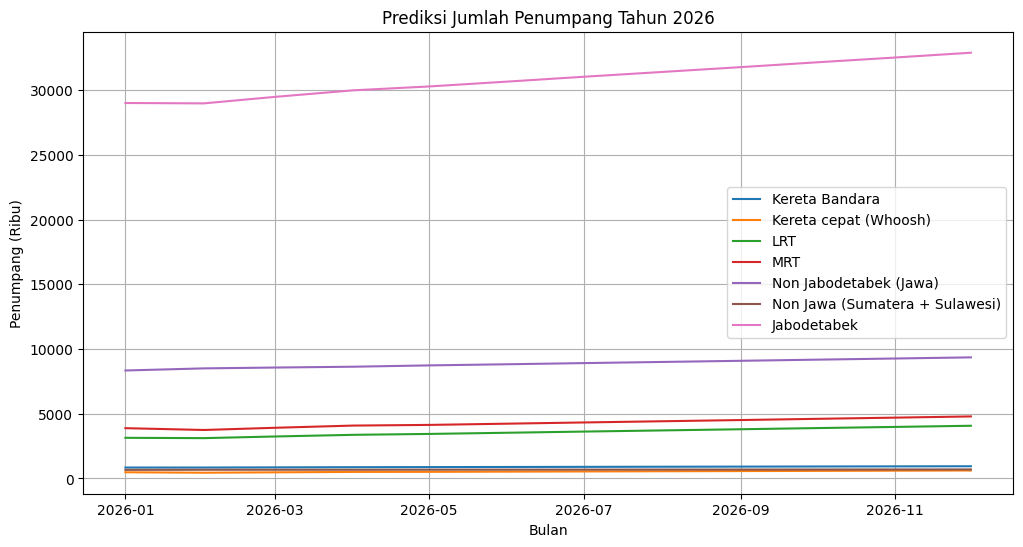

In [99]:
import matplotlib.pyplot as plt

df_hasil = pd.read_sql(
    text("SELECT * FROM hasil_prediksi_2026 ORDER BY Tanggal ASC"),
    engine
)


plt.figure(figsize=(12,6))

for kategori in df_hasil['Kategori'].unique():
    data = df_hasil[df_hasil['Kategori'] == kategori]

    plt.plot(
        data['Tanggal'],
        data['Prediksi_Penumpang_Ribu'],
        label=kategori
    )

plt.title('Prediksi Jumlah Penumpang Tahun 2026')
plt.xlabel('Bulan')
plt.ylabel('Penumpang (Ribu)')
plt.legend()
plt.grid(True)
plt.show()